## Training Notebook Requirement

The training notebook must save `model_config.json` after training completes.

**Add this function to your training notebook (secbert_smaller_teacher.ipynb) after training:**

```python


# Call after training:
# 
```

## Random Seed

In [57]:
import random
import torch
import numpy as np
import json


In [58]:
print(torch.__version__)

2.9.0+cu130


In [59]:

def set_seed(seed):
    # 設定 Python 隨機數生成器的種子
    random.seed(seed)
    
    # 設定 numpy 隨機數生成器的種子
    np.random.seed(seed)
    
    # 設定 PyTorch 隨機數生成器的種子
    torch.manual_seed(seed)
    
    # 如果使用 GPU，設置 CUDA 隨機數生成器的種子
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    # 設置 PyTorch 預測模式，保證可重現性
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 設定隨機種子
set_seed(22)


## Dataset

In [60]:
from transformers import AutoTokenizer
import torch

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-pretrain", local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/sec-bert-base")

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", local_files_only=True)

# 設定預設值
CLASSIFICATION_MISSING_VALUE = -100
NUMERIC_MISSING_VALUE = torch.finfo(torch.float32).max  # 3.4028235e+38

In [61]:
# batch
from concurrent.futures import ThreadPoolExecutor
import math
from tqdm import tqdm

def process_batch(batch, target_attrs, tokenizer):

    batch_results = []
    for job in batch:
        context_p = job['context'].get("context_p", "")
        context_t = job['context'].get("context_t", "")
        context_n = job['context'].get("context_n", "")
        # full_context = f"{context_t} [SEP] {context_p} [SEP] {context_n}"
        document_info = f"{job['document']['document_type']};{job['document']['period_end_date']};{job['document']['fiscal_year']};{job['document']['period_focus']}"
        full_context = f"{context_t} [SEP] {document_info} [SEP] {context_p} [SEP] {context_n}"

        tokenized = tokenizer(
            full_context,
            padding = "max_length",
            truncation = True,
            max_length = 512,
            return_tensors = "pt",
            return_offsets_mapping = True,
            return_special_tokens_mask = True,
        )

        token_ids = tokenized["input_ids"].squeeze(0)
        offset_mapping = tokenized["offset_mapping"].squeeze(0)

        # sep_indices = [idx for idx, token in enumerate(token_ids) if token == tokenizer.sep_token_id]
        # context_t_end = sep_indices[0] if sep_indices else len(token_ids) - 1
        
        for i, target in enumerate(job['targets']):
            start_char, end_char = target['start_pos'], target['end_pos']
            start_token, end_token = -1, -1

            for idx, (start, end) in enumerate(offset_mapping):
                # if idx > context_t_end:
                #     break
                if start <= start_char < end:
                    start_token = idx
                if start < end_char <= end:
                    end_token = idx
                    break
            
            # if start_token == -1 or end_token == -1 or start_token > context_t_end or end_token > context_t_end:
            if start_token == -1 or end_token == -1:
                continue 
                
            # print("\n=== DEBUG: Tokenization ===")
            # token_ids = tokenized["input_ids"].squeeze(0) 
            # tokens = tokenizer.convert_ids_to_tokens(token_ids.tolist())
            # print("Original Text:", full_context)
            # # print("Tokens:", tokens)
            # print("Offset Mapping:", offset_mapping)
            # print(f"Target Text: {target['text']} | Start Char: {start_char}, End Char: {end_char}")
            # print(f"Found Token Indices -> Start: {start_token}, End: {end_token}")
            # if start_token >= 0 and end_token >= 0:
            #     print(f"Matched Tokens: {tokens[start_token:end_token+1]}")
            # print("====================================\n")
            
            target_data = {
                "job_id": job["job_id"],
                "seq_id": target["seq_id"],
                "context": full_context,
                "input_ids": token_ids,
                "attention_mask": tokenized['attention_mask'].squeeze(0),
                "start_token": start_token,
                "end_token": end_token,
                "value": convert_span_to_number(target['text']),
                "doc_link": job['document']['document_link'],
            }
            
            for attr in target_attrs:
                if attr in ["tag", "time", "scale", "negative"]:  # 分類屬性
                    target_data[attr] = CLASSIFICATION_MISSING_VALUE
                elif attr == "fact":  # 數值屬性
                    target_data[attr] = NUMERIC_MISSING_VALUE

            gold_values = job['golds'][i]['value']
            for attr_idx, attr in enumerate(target['attribute']):
                value = gold_values[attr_idx]
                if attr == 'tag':
                    # 暫時先歸到 standard_rare 
                    if value in standard_rare_tags:
                        value = 'standard_rare'
                    target_data['tag'] = tag2id.get(value, -100)
                elif attr == 'time':
                    target_data['time'] = time2id.get(value, -100)
                elif attr == 'fact':
                    if value:
                        target_data['fact'] = float(value)
                        target_data['negative'] = 1 if value < 0 else 0
                    else:
                        target_data['fact'] = NUMERIC_MISSING_VALUE
                        target_data['negative'] = CLASSIFICATION_MISSING_VALUE
                    # target_data['fact'] = float(value)
                elif attr == 'scale':
                    target_data['scale'] = scale2id.get(value, -100)

               
                    
            batch_results.append(target_data)
    return batch_results

from concurrent.futures import ProcessPoolExecutor, TimeoutError


def process_batch_wrapper(args):
    """ 用於 `ProcessPoolExecutor` 的批次處理函數 """
    batch, target_attrs, tokenizer = args
    return process_batch(batch, target_attrs, tokenizer)

def process_data(data, target_attrs, tokenizer, batch_size = 32, num_workers = 8):
    inputs = []
    
    # 計算總批次數
    num_batches = math.ceil(len(data) / batch_size)

    # 將數據拆分成批次
    batches = [data[i * batch_size: (i + 1) * batch_size] for i in range(num_batches)]

    # 構建參數列表
    task_args = [(batch, target_attrs, tokenizer) for batch in batches]

    # 使用多進程處理批次
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(tqdm(executor.map(process_batch_wrapper, task_args), total=num_batches, desc="Processing Data"))

    # 合併所有批次的結果
    for res in results:
        inputs.extend(res)
    
    return inputs


In [62]:
# ===== LOAD MODEL CONFIG (Instead of recomputing from data) =====
# This ensures test uses EXACT SAME mappings as training!

import os

def load_model_config(config_path):
    """Load the model configuration saved during training."""
    if not os.path.exists(config_path):
        raise FileNotFoundError(
            f"❌ Config file not found: {config_path}\n"
            f"   Make sure the training notebook saved model_config.json"
        )
    
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)
    
    print(f"✅ Config loaded from: {config_path}")
    return config

# ===== CONFIGURATION BLOCK (Edit these to switch models!) =====
RUN_NAME = "secbert-0426-173"
MODEL_NAME = "secbert"
BASE_WEIGHT_DIR = "model_weight"

# Build config path
config_path = os.path.join(
    BASE_WEIGHT_DIR, MODEL_NAME, f"{RUN_NAME}_config.json"
)

# Load configuration
model_config = load_model_config(config_path)

# Extract mappings from config (NO RECOMPUTATION!)
tag2id = model_config["tag2id"]
id2tag = {int(k): v for k, v in model_config["id2tag"].items()}

time2id = model_config["time2id"]
id2time = {int(k): v for k, v in model_config["id2time"].items()}

scale2id = model_config["scale2id"]
id2scale = {int(k): v for k, v in model_config["id2scale"].items()}

# Extract constants
CLASSIFICATION_MISSING_VALUE = model_config["classification_missing_value"]
NUMERIC_MISSING_VALUE = model_config["numeric_missing_value"]

# Build derived lists for compatibility
tag_list = [tag2id[i] for i in sorted(tag2id.keys())]
time_list = [time2id[i] for i in sorted(time2id.keys())]
scale_list = [scale2id[i] for i in sorted(scale2id.keys())]
standard_rare_tags = set()  # Already handled in training

print(f"📊 Loaded mappings from config:")
print(f"   • Tags: {len(tag2id)} classes")
print(f"   • Times: {len(time2id)} classes")
print(f"   • Scales: {len(scale2id)} classes")

✅ Config loaded from: model_weight/secbert/secbert-0426-173_config.json
📊 Loaded mappings from config:
   • Tags: 978 classes
   • Times: 9 classes
   • Scales: 25 classes


In [63]:
import locale
from word2number import w2n

def convert_span_to_number(span):
    """
    將 span 轉換為數字。
    """
    span = span.strip()
    
    # 嘗試直接轉換為數字
    try:
        return locale.atof(span.replace(",", ""))  # 去掉千分位逗號並轉換
    except ValueError:
        pass  # 不是標準數字，繼續嘗試解析
    
    # 嘗試將文字轉為數字
    try:
        return w2n.word_to_num(span.lower())
    except ValueError:
        pass  # 不是可解析的數字
    
    return None  # 解析失敗，返回 None


#### IterableDataset

In [64]:
import random
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class MultiTaskIterableDataset(IterableDataset):
    ''' 讀取原始 JSONL 檔案，進行前處理'''

    def __init__(self, files, target_attrs, tokenizer, batch_size=32, num_workers=8):
        self.files = files
        self.target_attrs = target_attrs
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.num_workers = num_workers
    
    def _get_sharded_lines(self, file_path):
        """確保多進程時，每個 worker 讀不同的部分"""
        worker_info = get_worker_info()
        if worker_info is None:  # 單進程模式
            start, step = 0, 1
        else:
            start, step = worker_info.id, worker_info.num_workers  # worker id & 總數

        with open(file_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i % step == start:  # 讓不同 worker 讀不同的行
                    yield line
    def __iter__(self):
        """逐行讀取 JSONL 並轉換為數據格式"""
        for file_path in self.files:
            for line in self._get_sharded_lines(file_path):
                raw_data = json.loads(line)
                processed_data = process_batch([raw_data], self.target_attrs, self.tokenizer)
                for item in processed_data:
                    yield item
                    
class BufferedShuffleDataset(IterableDataset):
    """ 負責對 IterableDataset 進行 buffer shuffle """

    def __init__(self, dataset, buffer_size = 8000):
        self.dataset = dataset
        self.buffer_size = buffer_size

    def __iter__(self):
        buffer = []
        for sample in self.dataset:
            buffer.append(sample)
            if len(buffer) >= self.buffer_size:
                random.shuffle(buffer)
                while buffer:
                    yield buffer.pop()

        random.shuffle(buffer)
        while buffer:
            yield buffer.pop()

In [65]:
batch_size = 256
num_workers = 4
target_attrs = ["tag", "time", "scale", "negative", "fact"]

train_dataset = MultiTaskIterableDataset(
    files = ["../processed_data_task1_smaller/train_400k.jsonl"], 
    # files = ["processed_data_task1/train_data_shuffled.jsonl"],
    target_attrs = target_attrs,
    tokenizer = tokenizer)

valid_dataset = MultiTaskIterableDataset(
    files = ["../processed_data_task1_smaller/valid_50k.jsonl"], 
    # files = ["processed_data_task1/valid_data.jsonl"], 
    target_attrs = target_attrs,
    tokenizer = tokenizer)

test_dataset = MultiTaskIterableDataset(
    files = ["../processed_data_task1_smaller/test_50k.jsonl"], 
    # files = ["processed_data_task1/test_data.jsonl"], 
    target_attrs = target_attrs,
    tokenizer = tokenizer)

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, num_workers = num_workers)
valid_dataloader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = num_workers)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, num_workers = num_workers)

#### Load Processed Iterable Dataset

In [66]:
# 讀取處理後的 JSONL

import json
import torch
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class ProcessedIterableDataset(IterableDataset):
    def __init__(self, files):
        self.files = files

    def _get_sharded_lines(self, file_path):
        """確保多進程時，每個 worker 讀不同的部分"""
        worker_info = get_worker_info()
        if worker_info is None:  # 單進程模式
            start, step = 0, 1
        else:
            start, step = worker_info.id, worker_info.num_workers  # worker id & 總數

        with open(file_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i % step == start:  # 讓不同 worker 讀不同的行
                    yield line

    def __iter__(self):
        """讀取 JSONL 並轉換為合適格式"""
        sample_count = 0
        for file_path in self.files:
            for line in self._get_sharded_lines(file_path):
                raw_data = json.loads(line)

                # 把 list 轉回 torch.Tensor
                processed_data = {
                    key: torch.tensor(value) if isinstance(value, list) else value
                    for key, value in raw_data.items()
                }
                
                yield processed_data

            

train_files = ["processed_iterable_dataset/train_400k.jsonl"]
valid_files = ["processed_iterable_dataset/valid_50k.jsonl"] 
test_files = ["processed_iterable_dataset/test_50k.jsonl"]

train_dataset = ProcessedIterableDataset(train_files)

valid_dataset = ProcessedIterableDataset(valid_files)

test_dataset = ProcessedIterableDataset(test_files)

batch_size = 256
# train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
# valid_loader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)

In [67]:
import os

def count_lines(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return sum(1 for _ in f)

# 計算訓練資料大約的 batch 數
train_total_samples = sum(count_lines(f) for f in train_files)
train_approx_batches = train_total_samples // batch_size

valid_total_samples = sum(count_lines(f) for f in valid_files)
valid_approx_batches = valid_total_samples // batch_size

test_total_samples = sum(count_lines(f) for f in test_files)
test_approx_batches = test_total_samples // batch_size


print(f"Train 預計數量: {train_total_samples}, 預計 {train_approx_batches} 個 batch")
print(f"Valid 預計數量: {valid_total_samples}, 預計 {valid_approx_batches} 個 batch")
print(f"Test 預計數量: {test_total_samples}, 預計 {test_approx_batches} 個 batch")

Train 預計數量: 728821, 預計 2846 個 batch
Valid 預計數量: 91168, 預計 356 個 batch
Test 預計數量: 90337, 預計 352 個 batch


## Count

In [68]:
# IterableDataset

with open('../processed_data_task1_smaller/counter/tag_count_train_400k.json', 'r', encoding = 'utf-8') as file:
# with open('processed_iterable_dataset/counter/train_8k.json', 'r', encoding = 'utf-8') as file:
# with open('../processed_data_task1/counter/tag_count_train_data.json', 'r', encoding = 'utf-8') as file:    
    tag_counter = json.load(file)
    
# 想讓數量多的類別在前面

tag_counter = dict(sorted(tag_counter.items(), key = lambda item:item[1], reverse=True))
print(len(tag_counter))
count_threshold = 10
standard_rare_tags = {tag for tag, count in tag_counter.items() if count < count_threshold}
tag_list = [tag for tag in tag_counter.keys() if tag not in standard_rare_tags]
print(tag_list[:5])
print(f'Length of standard_rare_tags: {len(standard_rare_tags)}')
print(f'Length of all tags: {len(tag_list)}')

id2tag = {idx: tag for idx, tag in enumerate(tag_list)}
tag2id = {tag: idx for idx, tag in enumerate(tag_list)}

time_list = ['instant; past', 'instant; current', 'instant; future', 'period; past', 'period; current', 'period; future', 'period; past_current', 'period; current_future', 'period; past_future']
id2time = {idx: time for idx, time in enumerate(time_list)}
time2id = {time: idx for idx, time in enumerate(time_list)}

scale_list = [str(i) for i in range(-12, 13)]
id2scale = {idx: scale for idx, scale in enumerate(scale_list)}
scale2id = {scale: idx for idx, scale in enumerate(scale_list)}
# with open('processed_data_task1_smaller/counter/train_100k.json')

978
['custom', 'standard_rare', 'us-gaap:DebtInstrumentInterestRateStatedPercentage', 'us-gaap:DebtInstrumentBasisSpreadOnVariableRate1', 'us-gaap:DebtInstrumentFaceAmount']
Length of standard_rare_tags: 0
Length of all tags: 978


#### 計算 tag, scale, negative, time 的類別個數
計算後存成 JSON，之後可以直接用

In [69]:
# load counter result

def load_counter(target_attr):
    target_path = f'processed_iterable_dataset/counter/secbert_train_small_{target_attr}.json'

    with open(target_path, "r", encoding='utf-8') as f:
        data = json.load(f)
    return data

train_tag_counts = load_counter("tag")
train_tag_counts.pop('-100', None)
num_tag_samples = [train_tag_counts.get(str(tag2id[tag]), 0) for tag in tag_list]
print(f'Total tag class: {len(train_tag_counts)}')
train_time_counts = load_counter("time")
train_time_counts.pop('-100', None)
num_time_samples = [train_time_counts.get(str(time2id[time]), 0) for time in time_list]
print(train_time_counts)

train_neg_counts = load_counter("negative")
train_neg_counts.pop('-100', None)
num_neg_samples = [train_neg_counts.get(neg, 0) for neg in sorted(train_neg_counts.keys())]
print(train_neg_counts)

train_scale_counts = load_counter("scale")
train_scale_counts.pop('-100', None)
num_scale_samples = [train_scale_counts.get(str(scale2id[scale]), 0) for scale in scale_list]
print(train_scale_counts)

Total tag class: 978
{'6': 70691, '4': 124746, '3': 175155, '1': 195615, '0': 135307, '2': 14182, '5': 10629, '7': 351, '8': 490}
{'0': 701747, '1': 19527}
{'18': 328811, '10': 117673, '12': 152722, '15': 50895, '21': 18758, '8': 1695, '17': 38, '14': 13, '9': 20, '11': 18, '13': 17, '24': 30, '16': 37, '20': 2, '6': 5, '19': 3}


## Model

In [70]:
import torch
import torch.nn as nn
from transformers import BertModel, BertPreTrainedModel

class GateHead(nn.Module):
    """
    Multi-Task Gate Head that outputs separate noise scores for each task.
    
    Input: [CLS] token representation
    Output: Dictionary of 4 gates (one per task)
            {"tag": [0-1], "time": [0-1], "scale": [0-1], "negative": [0-1]}
            
    Each gate score represents the "noise probability":
        1 = High Noise (Ignore this sample for this task)
        0 = Clean Data (Learn from this sample for this task)
    """
    def __init__(self, hidden_size, dropout_prob=0.1):
        super().__init__()
        self.dense = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(dropout_prob)
        
        # Separate output heads for each task
        self.gate_tag = nn.Linear(hidden_size, 1)
        self.gate_time = nn.Linear(hidden_size, 1)
        self.gate_scale = nn.Linear(hidden_size, 1)
        self.gate_negative = nn.Linear(hidden_size, 1)
        
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Args:
            x: [CLS] token representation, shape (batch_size, hidden_size)
            
        Returns:
            Dictionary with per-task gate scores, each shape (batch_size, 1)
        """
        x = self.dropout(x)
        x = self.dense(x)
        x = torch.tanh(x)  # Tanh is standard for BERT pooler/heads
        x = self.dropout(x)
        
        # Compute gate scores for each task
        gate_tag = self.sigmoid(self.gate_tag(x))        # (batch_size, 1)
        gate_time = self.sigmoid(self.gate_time(x))
        gate_scale = self.sigmoid(self.gate_scale(x))
        gate_negative = self.sigmoid(self.gate_negative(x))
        
        return {
            "tag": gate_tag,
            "time": gate_time,
            "scale": gate_scale,
            "negative": gate_negative
        }


In [71]:
import torch.nn as nn
from transformers import BertModel

class MultiTaskModel(nn.Module):
    def __init__(self, bert_model_name, num_tags, num_times, num_scales):
        super(MultiTaskModel, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden_size = self.bert.config.hidden_size
        
        self.tag_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, num_tags)
        )

        self.time_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, num_times)
        )

        self.scale_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_size // 2, num_scales)
        )

        self.negative_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_size // 2, 2)
        )
        
        # Multi-task gate head (outputs 4 separate gates)
        self.gate_head = GateHead(hidden_size)
        
    def forward(self, input_ids, attention_mask, start_tokens, end_tokens):
        """
        Args:
            input_ids: (batch_size, seq_length)
            attention_mask: (batch_size, seq_length)
            start_tokens: (batch_size,) - start indices of target span
            end_tokens: (batch_size,) - end indices of target span
            
        Returns:
            Dictionary containing:
                - "tag": (batch_size, num_tags)
                - "time": (batch_size, num_times)
                - "scale": (batch_size, num_scales)
                - "negative": (batch_size, 2)
                - "gates": Dict with per-task gates
                    - "tag": (batch_size, 1)
                    - "time": (batch_size, 1)
                    - "scale": (batch_size, 1)
                    - "negative": (batch_size, 1)
        """
        # BERT output
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        cls_token = sequence_output[:, 0, :]
        
        # Aggregate target embeddings
        target_embeddings = [
            sequence_output[i, start_tokens[i]:end_tokens[i] + 1].mean(dim=0)
            for i in range(input_ids.size(0))
        ]  # batch_size 個 tensor，tensor size: (hidden_size,) 
        
        target_embeddings = torch.stack(target_embeddings)  # (batch_size, hidden_size)
        
        # Task predictions
        tag_logits = self.tag_head(target_embeddings)        # (batch_size, num_tags)
        time_logits = self.time_head(target_embeddings)      # (batch_size, num_times)
        scale_logits = self.scale_head(target_embeddings)    # (batch_size, num_scales)
        negative_logits = self.negative_head(target_embeddings)  # (batch_size, 2)
        
        # Task-specific gates
        gates = self.gate_head(cls_token)  # Dict of 4 gates, each (batch_size, 1)
        
        return {
            "tag": tag_logits,
            "time": time_logits,
            "scale": scale_logits,
            "negative": negative_logits,
            "gates": gates  # Dict: {"tag": gate, "time": gate, ...}
        }


In [72]:
import os
import json
import torch

def save_model_config(model, tag2id, time2id, scale2id, output_dir, run_name):
    """
    Saves the model configuration and ID mappings to a JSON file.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    config = {
        "run_name": run_name,
        "tag2id": tag2id,
        "time2id": time2id,
        "scale2id": scale2id,
        "id2tag": {int(v): k for k, v in tag2id.items()},
        "id2time": {int(v): k for k, v in time2id.items()},
        "id2scale": {int(v): k for k, v in scale2id.items()},
        "classification_missing_value": -100,
        "numeric_missing_value": float(torch.finfo(torch.float32).max),
        "model_args": {
            "bert_model_name": model.bert.config._name_or_path,
            "num_tags": len(tag2id),
            "num_times": len(time2id),
            "num_scales": len(scale2id),
            "hidden_size": model.bert.config.hidden_size,
        }
    }

    config_filename = f"{run_name}_config.json"
    config_path = os.path.join(output_dir, config_filename)

    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4, ensure_ascii=False)

    print(f"✅ Configuration saved to: {config_path}")
    return config_path

# SecBERT Multi-Task Model — Inference & Evaluation

**Refactored Testing Notebook** (v2.0)

This notebook loads a trained multi-task model and evaluates it on test data.

## Key Changes:
✅ Loads `model_config.json` instead of recomputing ID mappings from raw data
✅ Eliminates the critical ID shift bug between training and testing
✅ Strict CPU/CUDA device handling
✅ Dynamic checkpoint configuration (easy switching)
✅ Identical model definitions to training notebook

## Prerequisites:
1. Training notebook must save `model_config.json` (see section below)
2. Model checkpoint must exist at `model_weight/{MODEL_NAME}/{RUN_DATE}_{RUN_INDEX}_step{CHECKPOINT_STEP}.pt`
3. Test data must be available at the configured path

## Loss

In [73]:
# hits@k
import torch

def hits_at_k(predictions, targets, k=5):
    """
    計算 Hits@K 指標
    :param predictions: (batch_size, num_tags) - 預測分數
    :param targets: (batch_size, num_tags) - 目標標籤 (one-hot 或 multi-hot)
    :param k: 取前 K 個預測標籤
    :return: Hits@K 平均值
    """
    valid_mask = targets != -100  # 只保留有效的索引
    targets = targets[valid_mask]
    predictions = predictions[valid_mask]
    # print(f"targets.shape: {targets.shape}, targets min: {targets.min()}, targets max: {targets.max()}")
    # assert targets.min() >= 0, f"targets 包含負數: {targets}"

    top_k_preds = torch.topk(predictions, k, dim=-1).indices  # 取得 top-K 標籤索引

       # 確保 targets 維度正確
    if targets.dim() == 1:  # 若 targets 是索引格式 (batch_size,)
        targets = torch.nn.functional.one_hot(targets, num_classes=predictions.size(1))

    targets = targets.float()  # 確保是 float tensor

    # 判斷是否命中 top-K (batch_size, k) → (batch_size,)
    hits = torch.any(targets.gather(1, top_k_preds), dim=1).float()

    return hits.mean().item()  # 計算平均命中率

In [74]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# device = 'cpu'

cuda


In [75]:
# time loss
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# 取得 time 類別的出現次數
time_class_counts = torch.tensor(num_time_samples)

total_samples = sum(train_time_counts.values())
num_classes = len(train_time_counts)

time_class_weights = {
    cls: total_samples / (num_classes * count) 
    for cls, count in train_time_counts.items()
}
time_class_weights = dict(sorted(time_class_weights.items(), key = lambda item:item[0]))
time_class_weights = list(time_class_weights.values())

time_smoothed_weights = np.log1p(time_class_weights)

MIN_WEIGHT =  1 # 設定最小值
time_smoothed_weights = np.clip(time_smoothed_weights, MIN_WEIGHT, None)
time_smoothed_weights[0] = 1.5
time_smoothed_weights[6] = 1.5
print(time_smoothed_weights)
time_class_weights = torch.tensor(time_smoothed_weights, dtype=torch.float).to(device)
time_loss_fn = nn.CrossEntropyLoss(weight = time_class_weights, ignore_index = CLASSIFICATION_MISSING_VALUE)

[1.5        1.         1.90167407 1.         1.         2.15193528
 1.5        5.44323412 5.11132642]


In [76]:
# scale loss
scale_class_weights = {
    15: 1.2,  21: 1.5
}
num_classes = len(scale_list)
weights_list = [scale_class_weights.get(i, 1.0) for i in range(num_classes)]

scale_class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

# 定義 loss function
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE)

In [77]:
# # netagive loss

# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class FocalLoss(nn.Module):
#     '''https://doi.org/10.1109/tpami.2018.2858826'''
#     def __init__(self, alpha=0.25, gamma=2.0, reduction="mean", ignore_index = CLASSIFICATION_MISSING_VALUE):
#         """
#         alpha: 平衡因子 (適用於正負類不平衡)
#         gamma: 縮放因子 (讓難分類的樣本 loss 權重變高)
#         reduction: 可選 ["mean", "sum", "none"]，控制 loss 的輸出方式
#         """
#         super(FocalLoss, self).__init__()
#         if isinstance(alpha, (float, int)):  # 確保 alpha 是 tensor
#             self.alpha = torch.tensor([1 - alpha, alpha])  # alpha_neg, alpha_pos
#         else:
#             self.alpha = torch.tensor(alpha) 
#         self.gamma = gamma
#         self.reduction = reduction
#         self.ce_loss = nn.CrossEntropyLoss(reduction="none", ignore_index=CLASSIFICATION_MISSING_VALUE)
#         self.ignore_index = ignore_index

#     def forward(self, logits, targets):
#         """
#         logits: 預測值 (模型輸出，形狀 [batch_size, 2]，未經 softmax)
#         targets: 標籤值 (形狀 [batch_size]，0 或 1)
#         """
#         device = logits.device
#         self.alpha = self.alpha.to(device)
#         # print('focal loss', targets)
#         # print(targets.shape)
#         if targets.dim() > 1:
#             targets = targets.argmax(dim=-1)
        
#          # 1. 移除 ignore_index
#         valid_mask = (targets != self.ignore_index)
#         targets = targets[valid_mask]
#         logits = logits[valid_mask]

#         # if targets.numel() == 0:  # 避免 loss 計算時出現空值
#         #     return torch.tensor(0.0, device=device, requires_grad=True)
#         # if torch.any(filtered_targets < 0) or torch.any(filtered_targets >= logits.shape[-1]):
#         #     raise ValueError(f"Invalid target values detected: {filtered_targets}")
        
#         # 2. 計算 CrossEntropyLoss
#         ce_loss = self.ce_loss(logits, targets)  # 計算 cross entropy loss
#         pt = torch.exp(-ce_loss)  # 選擇正確類別的機率
        
#         # 4. 計算 focal loss 權重
#         focal_weight = (1 - pt) ** self.gamma  # (1 - p_t)^gamma
#         alpha_weight = self.alpha.gather(0, targets.data.view(-1))  # 根據 targets 索引 alpha

#         loss = alpha_weight * focal_weight * ce_loss

#         # 5. 根據 reduction 返回 loss
#         if self.reduction == "mean":
#             return loss.mean() if loss.numel() > 0 else torch.tensor(0.0, device=device, requires_grad=True)
#         elif self.reduction == "sum":
#             return loss.sum()
#         else:
#             return loss  # 不做平均，返回 batch loss

# neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="mean")

In [78]:
# # tag loss
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class CB_CE_Loss(nn.Module):
#     '''
#     https://ieeexplore.ieee.org/abstract/document/8953804
#     '''
#     def __init__(self, num_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE):
#         """
#         Args:
#             num_samples: list or tensor, 每個類別的樣本數
#             beta: 控制 class-balanced 權重的超參數 (通常取 0.99)
#         """
#         super(CB_CE_Loss, self).__init__()
        
#         # 計算 Class-Balanced 權重
#         effective_num = 1.0 - torch.pow(torch.tensor(beta), torch.tensor(num_samples))
#         weights = (1.0 - beta) / (effective_num + 1e-8)
#         # self.weights = weights / torch.sum(weights)  # normalize
#         self.weights = weights
#         self.ignore_index = ignore_index
        
#     def forward(self, logits, targets):
#         """
#         Args:
#             logits: (batch_size, num_classes) 模型輸出的 logits
#             targets: (batch_size,) 類別索引標籤
#         Returns:
#             CB-CE Loss 值
#         """
        
#         if targets.dim() > 1:
#             targets = targets.argmax(dim=-1)
            
#         valid_mask = (targets != self.ignore_index)  # 只對有效的 targets 計算 loss
#         targets = targets[valid_mask]
#         logits = logits[valid_mask]
        
#         # 計算標準 CE Loss
#         ce_loss = F.cross_entropy(logits, targets, reduction='none', ignore_index=self.ignore_index)
        
#         # 依照類別權重調整 loss
#         class_weights = self.weights.to(logits.device)
#         weighted_loss = ce_loss * class_weights[targets]
        
#         # weighted_loss = ce_loss * class_weights[targets] * weight_mask.float()
#         return torch.mean(weighted_loss)

#         # return weighted_loss.sum() / weight_mask.sum()  # 只對有效樣本取平均

# # train_tag_counts = get_value_counts(train_loader, "tag")
# # num_tag_samples = [train_tag_counts.get(tag, 0) for tag in sorted(train_tag_counts.keys())]  # 確保對應到索引順序
# tag_loss_fn = CB_CE_Loss(num_tag_samples, beta = 0.99)

In [79]:
# # train_time_counts = get_value_counts(train_loader, "time")
# # num_time_samples = [train_time_counts.get(time, 0) for time in sorted(train_time_counts.keys())]
# time_loss_fn = CB_CE_Loss(num_time_samples)

In [80]:
# fact loss

def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = torch.abs(error) < delta
    squared_loss = 0.5 * error ** 2
    linear_loss = delta * (torch.abs(error) - 0.5 * delta)
    return torch.where(is_small_error, squared_loss, linear_loss).mean()

def signed_log(x):
    return torch.sign(x) * torch.log1p(torch.abs(x))  # 保留正負號

def fact_loss_fn(fact_pred, fact_target):
    # 過濾特殊值
    valid_mask = fact_target != NUMERIC_MISSING_VALUE
    fact_pred = fact_pred[valid_mask]
    fact_target = fact_target[valid_mask]
    
    #  signed log 轉換
    fact_target_log = signed_log(fact_target)
    fact_pred_log = signed_log(fact_pred)

    #  # 設定 Hybrid Loss 的閾值
    threshold = 8.0

    # # 小於 threshold 用 Huber Loss，大於 threshold 用 MSE
    use_huber = fact_target_log.abs() < threshold
    use_mse = ~use_huber

    huber_part = huber_loss(fact_pred_log[use_huber], fact_target_log[use_huber]) if use_huber.any() else 0
    mse_part = mse_loss(fact_pred_log[use_mse], fact_target_log[use_mse]) if use_mse.any() else 0

    # 最終 loss
    return huber_part + mse_part
    

In [81]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- 1. Focal Loss (Updated for reduction='none') ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="none", ignore_index=-100):
        super(FocalLoss, self).__init__()
        # ... (init logic same as before) ...
        if isinstance(alpha, (float, int)): 
            self.alpha = torch.tensor([1 - alpha, alpha])
        else:
            self.alpha = torch.tensor(alpha)
        self.gamma = gamma
        self.reduction = reduction # Default is now 'none'
        self.ce_loss = nn.CrossEntropyLoss(reduction="none", ignore_index=ignore_index)
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        device = logits.device
        self.alpha = self.alpha.to(device)
        
        if targets.dim() > 1:
            targets = targets.argmax(dim=-1)
            
        # Standard Cross Entropy (Returns vector [batch_size])
        ce_loss = self.ce_loss(logits, targets) 
        pt = torch.exp(-ce_loss)
        
        # Calculate weights
        focal_weight = (1 - pt) ** self.gamma
        
        # Handle ignore_index safely for alpha lookup
        # We clamp target indices just for the lookup to avoid crash, the loss will be masked anyway by ce_loss
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0 
        alpha_weight = self.alpha.gather(0, safe_targets.view(-1))
        
        loss = alpha_weight * focal_weight * ce_loss
        
        # Mask out ignore_index manually since alpha lookup might have been affected
        loss = torch.where(targets != self.ignore_index, loss, torch.zeros_like(loss))

        if self.reduction == "mean":
            return loss.sum() / (targets != self.ignore_index).sum()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss  # Returns [batch_size]

# --- 2. Class Balanced Loss (Updated for reduction='none') ---
class CB_CE_Loss(nn.Module):
    def __init__(self, num_samples, beta=0.99, ignore_index=-100):
        super(CB_CE_Loss, self).__init__()
        effective_num = 1.0 - torch.pow(torch.tensor(beta), torch.tensor(num_samples))
        weights = (1.0 - beta) / (effective_num + 1e-8)
        self.weights = weights
        self.ignore_index = ignore_index
        
    def forward(self, logits, targets):
        if targets.dim() > 1:
            targets = targets.argmax(dim=-1)
            
        # Calculate standard CE Loss (Vector)
        ce_loss = F.cross_entropy(logits, targets, reduction='none', ignore_index=self.ignore_index)
        
        # Class Weights
        class_weights = self.weights.to(logits.device)
        
        # Safe lookup for weights (handle ignore_index)
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0
        sample_weights = class_weights[safe_targets]
        
        weighted_loss = ce_loss * sample_weights
        
        # Ensure ignored indices are truly 0
        weighted_loss = torch.where(targets != self.ignore_index, weighted_loss, torch.zeros_like(weighted_loss))
        
        return weighted_loss # Returns [batch_size]

In [82]:
# --- Tag Loss ---
# (Assumes you have num_tag_samples defined as before)
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE)

# --- Time Loss ---
# (Assumes you have time_class_weights defined as before)
# Note: standard CrossEntropyLoss supports reduction='none' by default
time_loss_fn = nn.CrossEntropyLoss(weight=time_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Scale Loss ---
# (Assumes scale_class_weights defined)
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Negative Loss ---
neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="none")

In [83]:
# # loss function

# classification_loss = nn.CrossEntropyLoss(ignore_index = CLASSIFICATION_MISSING_VALUE)
# mse_loss = nn.MSELoss()

# def compute_loss(outputs, targets, values, task_weights = None, hits_k = False):
#     losses = {}
#     tag_hits_k = {}
#     if "tag" in targets:
#         losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

#         # if not model.training:
#         if hits_k:
#             tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k = 1)
#             tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k = 3)
#             tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k = 5)

#     if "time" in targets:
#         losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
#     if "scale" in targets:
#         losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    
#     if "negative" in targets:
#         # 負號預測
#         negative_pred = outputs["negative"].argmax(dim=-1)  # [batch_size]
#         losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
    
#     total_loss = sum(task_weights[k] * losses[k] for k in losses.keys())
    
#     # 平衡 loss 避免變大
#     total_loss = total_loss / sum(task_weights.values())

#     # print('total_loss', total_loss)
#     return (total_loss, losses, tag_hits_k) if hits_k else (total_loss, losses)

In [84]:
# --- Tag Loss ---
# (Assumes you have num_tag_samples defined as before)
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE)

# --- Time Loss ---
# (Assumes you have time_class_weights defined as before)
# Note: standard CrossEntropyLoss supports reduction='none' by default
time_loss_fn = nn.CrossEntropyLoss(weight=time_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Scale Loss ---
# (Assumes scale_class_weights defined)
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Negative Loss ---
neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="none")

In [85]:
CLASSIFICATION_MISSING_VALUE=-100
classification_loss = nn.CrossEntropyLoss(ignore_index = CLASSIFICATION_MISSING_VALUE)
mse_loss = nn.MSELoss()


In [86]:
def compute_loss(outputs, targets, values, task_weights=None, gate_reg_weights=None, hits_k=False):
    """
    Compute loss with task-specific gating and regularization.
    
    Formula for each task:
        L_task_final = (1 - g_task) * L_task_raw + lambda_task * (g_task)^2
    
    Total Loss = sum(task_weights[task] * L_task_final for all tasks)
    
    Args:
        outputs: Dict from model forward pass, includes "gates" key
        targets: Dict of target tensors
        values: Tensor of numeric values (for fact prediction)
        task_weights: Dict mapping task names to their importance weights
        gate_reg_weights: Dict mapping task names to gate regularization lambdas
                         Controls how strongly the gate is regularized
                         Higher lambda = harder to ignore samples for this task
                         Default is 1.0 for all tasks
        hits_k: Whether to compute Hits@K metrics for tag task
        
    Returns:
        (total_loss, losses_log) if hits_k=False
        (total_loss, losses_log, tag_hits_k) if hits_k=True
    """
    # Default values
    if task_weights is None:
        task_weights = {"tag": 1.0, "time": 1.0, "scale": 1.0, "negative": 1.0}
    if gate_reg_weights is None:
        gate_reg_weights = {"tag": 1.0, "time": 1.0, "scale": 1.0, "negative": 1.0}
    
    losses = {}
    
    # --- 1. Calculate Raw Vector Losses [batch_size] ---
    if "tag" in targets:
        losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

    if "time" in targets:
        losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
    if "scale" in targets:
        losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    
    if "negative" in targets:
        losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
    
    # --- 2. Extract Gates (per-task) ---
    gates = outputs.get("gates", {})  # Dict of gates, each (batch_size, 1)
    
    # Initialize total loss vector
    device = list(losses.values())[0].device
    total_loss_vec = torch.zeros(losses[list(losses.keys())[0]].shape[0], device=device)
    
    # --- 3. Apply Gate-based Loss Weighting Per Task ---
    # Formula: L_task_final = (1 - g_task) * L_task_raw + lambda_task * (g_task)^2
    for task_name, raw_loss in losses.items():
        gate = gates[task_name].squeeze(-1)  # (batch_size, 1) -> (batch_size,)
        lambda_task = gate_reg_weights.get(task_name, 1.0)
        task_weight = task_weights.get(task_name, 1.0)
        
        # Apply gate weighting
        gated_loss = (1 - gate) * raw_loss + lambda_task * gate.pow(2)
        
        # Add task-weighted contribution to total loss
        total_loss_vec += task_weight * gated_loss
    
    # --- 4. Final Average Loss ---
    total_loss = total_loss_vec.mean()
    
    # --- 5. Prepare Logging Dict (Convert vectors to scalar means for display) ---
    losses_log = {k: v.mean().item() for k, v in losses.items()}
    
    # Log gate statistics per task
    for task_name, gate in gates.items():
        gate_mean = gate.mean().item()
        gate_std = gate.std().item() if gate.numel() > 1 else 0.0
        losses_log[f'gate_{task_name}_mean'] = gate_mean
        losses_log[f'gate_{task_name}_std'] = gate_std
        losses_log[f'lambda_{task_name}'] = gate_reg_weights.get(task_name, 1.0)
    
    # --- 6. Hits@K (Optional) ---
    tag_hits_k = {}
    if hits_k and "tag" in targets:
        tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k=1)
        tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k=3)
        tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k=5)

    return (total_loss, losses_log, tag_hits_k) if hits_k else (total_loss, losses_log)


In [87]:
# def compute_loss(outputs, targets, values, task_weights = None, hits_k = False):
#     losses = {}
#     tag_hits_k = {}
#     if "tag" in targets:
#         losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

#         if hits_k:
#             tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k = 1)
#             tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k = 3)
#             tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k = 5)

#     if "time" in targets:
#         losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
#     if "scale" in targets:
#         losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    
#     if "negative" in targets:
#         losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
    
#     # gate: [batch_size, 1] -> [batch_size]
#     gate = outputs["gate"].squeeze(-1)
    
#     # Compute weighted sum of task losses: sum over tasks
#     # Each task loss is a scalar (already reduced by their respective loss functions)
#     total_raw_loss = sum(task_weights[k] * losses[k] for k in losses.keys())
    
#     # Apply gate weighting and regularization
#     # (1 - gate) * total_loss +  gate^2
#     weighted_loss = (1 - gate) * total_raw_loss + gate.pow(2)
    

#     # Normalize by task weights sum
#     total_loss = weighted_loss / sum(task_weights.values())
#     return (total_loss, losses, tag_hits_k) if hits_k else (total_loss, losses)   

# 恢復訓練

In [88]:
import wandb
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from transformers import get_scheduler
from tqdm import tqdm
import os

num_warmup_steps = 5
num_epochs = 30
eval_step = 20000 # 150222 個 batch
# checkpoint_save_step = 50
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}  
# task_weights = get_task_weights(0)
patience = 5
max_saved_models = 2
saved_models = [] 

model_name = "secbert"
date = "0426"
index = 173
run_name = f"{model_name}-{date}-{index}"

model = MultiTaskModel(
    "nlpaueb/sec-bert-base",
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)


bert_lr = 1e-5
tag_head_lr = 5e-4
time_head_lr = 1e-5
scale_head_lr = 3e-5
negative_head_lr = 2e-5

optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
])

num_total_steps= num_epochs * train_approx_batches
scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)

device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
print(device)
best_val_loss = float("inf")
early_stop_counter = 0 


os.makedirs(f'model_weight/{model_name}', exist_ok=True)
os.makedirs(f'check_point/{model_name}', exist_ok=True)


# import wandb

# # generate a new run name or ID if needed
# run_name = f"{model_name}-{date}-{index}-gate_mechanism"

# wandb.init(
#     project="multi-task-model",
#     name=run_name,
#     # Remove 'id' and 'resume' if this is a fresh start for the new model logic
#     # id='new_id_here', 
#     # resume="allow", 
#     config={
#         "epochs": num_epochs,
#         "batch_size": batch_size,
#         "learning_rates": { 
#             "bert": bert_lr,
#             "tag_head": tag_head_lr,
#             "time_head": time_head_lr,
#             "scale_head": scale_head_lr,
#             "negative_head": negative_head_lr,
#             "gate_head": bert_lr # or whatever custom LR you used for gate
#         },
#         "task_weights": task_weights,
#         "train_data_size": train_total_samples,
#         "model_architecture": "SecBERT + GateHead + HybridLoss"
#     }
# )

# # Optional: Watch the model to see gradients (specifically helpful to see if GateHead is dying)
# wandb.watch(model, log="gradients", log_freq=100)
# # wandb.watch(model, log="all")

 

cuda


In [89]:
# ---------------------------------------------------------
# ONLY RUN THIS CELL AFTER YOUR MODEL IS DEFINED AND TRAINED
# ---------------------------------------------------------
model_name="secbert"
# Ensure output directory exists (based on your script variables)
output_dir = os.path.join("model_weight", model_name) # e.g. model_weight/secbert

save_model_config(
    model=model,      # This variable must exist!
    tag2id=tag2id,    # This variable must exist!
    time2id=time2id,  # This variable must exist!
    scale2id=scale2id, # This variable must exist!
    output_dir=output_dir,
    run_name=run_name # This variable must exist!
)

✅ Configuration saved to: model_weight/secbert/secbert-0426-173_config.json


'model_weight/secbert/secbert-0426-173_config.json'

# Test

In [90]:
# model.to(device)
from collections import defaultdict
import csv
import os
import torch
import pandas as pd

def evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, save_errors=False):
    os.environ["WANDB_DISABLED"] = "true"
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    
    all_losses = {'tag': 0, 'time': 0, 'fact': 0, 'scale': 0, 'negative': 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)  # 存放錯誤樣本
    test_samples = 0
    test_batch_count = 0

    
    fact_res = []
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k = True)
            test_samples += len(batch["input_ids"])
            test_batch_count += 1
            
            # print(outputs)
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
                    
            for key in all_losses:
                if key in losses:
                    # all_losses[key] += losses[key].item()
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
                
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()

                # **移除 -100 (ignore_index)**
                for i, (p, t) in enumerate(zip(pred, true)):
                    # if t != CLASSIFICATION_MISSING_VALUE:
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    if p != t:  # **記錄錯誤預測**
                        errors[key].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

            # **處理數值預測 (fact)**
            if "fact" in targets:
                 # 負號預測
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                losses["negative"] = classification_loss(outputs["negative"], targets["negative"])
                
                #  Scale 預測
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)  # [batch_size]
            
                # scale → 數值
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)  
                scale_pred_values = id2scale_np[scale_pred_class] # [batch_size]

                values = values.cpu().numpy()

                # 計算 fact_pred
                fact_pred = values * (-1) ** negative_pred * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()

                for i, (p, t, neg, scale, scale_val, val) in enumerate(zip(fact_pred, fact_target, negative_pred, scale_pred_class, scale_pred_values, values)):
                    if t == NUMERIC_MISSING_VALUE:
                        continue
                
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                   
                    fact_res.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "true": t,
                        "pred": p,
                        "negative_pred": neg,
                        "scale_pred": scale,
                        "scale_val": scale_val,
                        "value": val
                    })
                    if abs(p - t) > 1e-2:  # 判斷是否錯誤
                        errors["fact"].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

    for key in all_losses:
        all_losses[key] /= test_batch_count
    
    # **平均 batch 結果**
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits}
        

    # **存錯誤樣本到 CSV**
    if save_errors:
        for key, error_list in errors.items():
            error_file = f"{error_file_path}_errors_{key}.csv"
            with open(error_file, mode="w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=["batch_idx", "sample_idx", "true", "pred"])
                writer.writeheader()
                writer.writerows(error_list)
            print(f"🚨 錯誤樣本已儲存到 {error_file}")

    if fact_res:
        fact_res_df = pd.DataFrame(fact_res)
        fact_res_df.to_csv('fact_res.csv', index = False)
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k


In [91]:
# ========================================================================
# ===== IMPROVED EVALUATION FUNCTION (Compatible with Multi-Gate Model) =====
# ========================================================================

import numpy as np
import pandas as pd
from collections import defaultdict
import csv
from tqdm import tqdm
import os
import torch

def evaluate_model(
    model,
    test_loader,
    device,
    task_weights,
    error_file_path,
    save_errors=False,
    verbose=True
):
    """
    Evaluate the model on test data.
    Modified to handle models returning a dictionary of multiple gates.
    """
    
    os.environ["WANDB_DISABLED"] = "true"
    model.eval()
    
    all_losses = {"tag": 0, "time": 0, "fact": 0, "scale": 0, "negative": 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)
    
    test_batch_count = 0
    fact_results = []
    
    # Use tqdm if verbose
    loader = tqdm(test_loader, desc="Evaluating") if verbose else test_loader
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            # ===== Load batch to device =====
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            # ===== Forward pass =====
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
            # ===== Compute loss =====
            # Note: Ensure your compute_loss can handle the 'gates' dict or ignores it safely
            loss, losses, tag_hits_k = compute_loss(
                outputs, targets, values, task_weights, hits_k=True
            )
            
            # ===== Extract gate values for debugging (FIXED BLOCK) =====
            # The model returns "gates" (dict of 4 tensors) but logic expects "gate" (1 tensor)
            if "gate" in outputs:
                # Case 1: Model returns a single gate tensor
                gate_tensor = outputs["gate"]
            elif "gates" in outputs and isinstance(outputs["gates"], dict):
                # Case 2: Model returns a dict of task-specific gates
                # Solution: Average the 4 gates to get a single "noise score" for logging
                gates_dict = outputs["gates"]
                # Sum all gate tensors (tag + time + scale + negative)
                sum_gates = sum(gates_dict.values()) 
                # Divide by number of tasks to get average
                gate_tensor = sum_gates / len(gates_dict)
            else:
                # Case 3: Fallback (should not happen with correct model)
                gate_tensor = torch.zeros(input_ids.size(0), 1).to(device)

            # Now we have a single tensor to convert to list
            gate_values = gate_tensor.squeeze(-1).cpu().tolist()
            predictions["gate"].extend(gate_values)
            
            test_batch_count += 1
            
            # ===== Aggregate metrics =====
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
            
            for key in all_losses:
                if key in losses:
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
            
            # ===== Classification predictions (tag, time, scale, negative) =====
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()
                
                for i, (p, t) in enumerate(zip(pred, true)):
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    
                    if p != t:
                        errors[key].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                            "gate": gate_values[i]
                        })
            
            # ===== Fact (Numeric) Predictions =====
            if "fact" in targets:
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()
                
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()
                else:
                    scale_pred_class = np.ones_like(
                        values.cpu().numpy(), dtype=np.int64
                    )
                
                # Convert scale IDs to actual scale values
                id2scale_np = np.array(
                    [float(id2scale[idx]) for idx in range(len(id2scale))],
                    dtype=np.float64
                )
                scale_pred_values = id2scale_np[scale_pred_class]
                
                values_np = values.cpu().numpy()
                fact_pred = (
                    values_np * ((-1) ** negative_pred) * (10 ** scale_pred_values)
                )
                fact_target = targets["fact"].view(-1).cpu().numpy()
                
                for i, (p, t, neg, scale, scale_val, val) in enumerate(
                    zip(
                        fact_pred,
                        fact_target,
                        negative_pred,
                        scale_pred_class,
                        scale_pred_values,
                        values_np,
                    )
                ):
                    # Skip missing values
                    if t == NUMERIC_MISSING_VALUE or t > 1e30:
                        continue
                    
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                    fact_results.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "true": t,
                        "pred": p,
                        "negative_pred": int(neg),
                        "scale_pred": int(scale),
                        "scale_val": float(scale_val),
                        "value": float(val),
                        "gate": gate_values[i]
                    })
                    
                    # Check for error (absolute difference > threshold)
                    if abs(p - t) > 1e-2:
                        errors["fact"].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": float(t),
                            "pred": float(p),
                            "gate": gate_values[i]
                        })
    
    # ===== Average metrics =====
    for key in all_losses:
        all_losses[key] /= test_batch_count if test_batch_count > 0 else 1
    
    avg_hits_k = {
        key: total_hits[key] / test_batch_count
        for key in total_hits
        if test_batch_count > 0
    }
    
    # ===== Save errors to CSV =====
    if save_errors:
        for key, error_list in errors.items():
            if error_list:
                error_file = f"{error_file_path}_errors_{key}.csv"
                fieldnames = ["batch_idx", "sample_idx", "true", "pred", "gate"]
                with open(error_file, mode="w", newline="", encoding="utf-8") as f:
                    writer = csv.DictWriter(f, fieldnames=fieldnames)
                    writer.writeheader()
                    writer.writerows(error_list)
                if verbose:
                    print(f"🚨 {len(error_list)} {key} errors saved to {error_file}")
    
    # ===== Save fact results to CSV =====
    if fact_results:
        fact_results_df = pd.DataFrame(fact_results)
        fact_csv_path = f"{error_file_path}_fact_results.csv"
        fact_results_df.to_csv(fact_csv_path, index=False, encoding="utf-8")
        if verbose:
            print(f"💾 Fact results saved to {fact_csv_path}")
    
    if verbose:
        print(f"\n✅ Evaluation complete!")
        print(f"   Test batches: {test_batch_count}")
        print(f"   Losses: {all_losses}")
        print(f"   Hits@K: {avg_hits_k}")
    
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k

In [92]:
# ============================================================================
# ===== DYNAMIC CONFIGURATION BLOCK (Edit these to switch checkpoints!) =====
# ============================================================================

# Model checkpoint identifiers
RUN_DATE = "0426"                    # e.g., "0426" (for file naming)
RUN_INDEX = 173                      # e.g., 173
CHECKPOINT_STEP = 30001              # e.g., 20001 (the actual checkpoint to load)
OUTPUT_DATE = 1203                   # e.g., 1203 (output directory naming)

# Device handling (auto-detect, but allow override)
FORCE_CPU = False  # Set to True to force CPU even if GPU is available
device = torch.device("cpu") if FORCE_CPU else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print(f"🖥️  Using device: {device}")

# Extract model args from config
model_args = model_config["model_args"]
num_tags = model_args["num_tags"]
num_times = model_args["num_times"]
num_scales = model_args["num_scales"]

# ============================================================================
# ===== CREATE MODEL INSTANCE =====
# ============================================================================

model = MultiTaskModel(
    bert_model_name=model_args["bert_model_name"],
    num_tags=num_tags,
    num_times=num_times,
    num_scales=num_scales
)

# ============================================================================
# ===== LOAD MODEL WEIGHTS (with proper error handling) =====
# ============================================================================

base_weight_dir = "model_weight"
base_error_dir = "error_analysis"

# Build checkpoint path dynamically
checkpoint_path = os.path.join(
    base_weight_dir,
    MODEL_NAME,
    f"{RUN_DATE}_{RUN_INDEX}_step{CHECKPOINT_STEP}.pt"
)
print(f"🔄 Loading model checkpoint from: {checkpoint_path}")
# Ensure checkpoint exists
if not os.path.exists(checkpoint_path):
    available_files = os.listdir(os.path.dirname(checkpoint_path)) if os.path.exists(os.path.dirname(checkpoint_path)) else []
    raise FileNotFoundError(
        f"❌ Model checkpoint not found: {checkpoint_path}\n"
        f"   Available files: {available_files[:5]}..."
    )

# Load weights with proper device mapping
try:
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f"✅ Model weights loaded from: {checkpoint_path}")
except RuntimeError as e:
    print(f"❌ Error loading state_dict: {e}")
    raise

# Move model to device and set to eval mode
model.to(device)
model.eval()

print(f"✅ Model ready on device: {device}")

# ============================================================================
# ===== SET UP ERROR OUTPUT DIRECTORY =====
# ============================================================================

os.makedirs(base_error_dir, exist_ok=True)
error_file_path = os.path.join(
    base_error_dir,
    f"{MODEL_NAME}_{RUN_DATE}_{RUN_INDEX}"
)

# Task weights (same as training)
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}

# ============================================================================
# ===== RUN EVALUATION =====
# ============================================================================

print("\n" + "="*70)
print("STARTING EVALUATION")
print("="*70)
print(f"Model: {RUN_NAME}")
print(f"Checkpoint: Step {CHECKPOINT_STEP}")
print(f"Device: {device}")
print("="*70 + "\n")

test_all_losses, test_predictions, test_ground_truths, avg_hits_k = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    task_weights=task_weights,
    error_file_path=error_file_path,
    save_errors=True,
    verbose=True
)
print(test_all_losses)
print(avg_hits_k)

# ============================================================================
# ===== SAVE RESULTS TO CSV =====
# ============================================================================

attrs = ["scale", "negative", "tag", "time", "fact"]
os.makedirs("result", exist_ok=True)

for attr in attrs:
    if attr in test_predictions and attr in test_ground_truths:
        df = pd.DataFrame({
            f"true_{attr}": test_ground_truths[attr],
            f"pred_{attr}": test_predictions[attr],
        })
        
        result_path = os.path.join(
            "result",
            f"{MODEL_NAME}_{RUN_DATE}_{RUN_INDEX}_result_{attr}.csv"
        )
        
        df.to_csv(result_path, index=False, encoding="utf-8")
        print(f"✅ Saved {attr} results to {result_path} ({len(df)} samples)")

print("\n" + "="*70)
print("EVALUATION COMPLETE")
print("="*70)
print(f"Run: {RUN_NAME}")
print(f"Checkpoint: Step {CHECKPOINT_STEP}")
print(f"Device: {device}")
print(f"Total test samples: {sum(len(v) for v in test_ground_truths.values())}")
print("="*70)

🖥️  Using device: cuda
🔄 Loading model checkpoint from: model_weight/secbert/0426_173_step30001.pt
🔄 Loading model checkpoint from: model_weight/secbert/0426_173_step30001.pt
✅ Model weights loaded from: model_weight/secbert/0426_173_step30001.pt
✅ Model ready on device: cuda

STARTING EVALUATION
Model: secbert-0426-173
Checkpoint: Step 30001
Device: cuda

✅ Model weights loaded from: model_weight/secbert/0426_173_step30001.pt
✅ Model ready on device: cuda

STARTING EVALUATION
Model: secbert-0426-173
Checkpoint: Step 30001
Device: cuda



Evaluating: 356it [03:29,  1.70it/s]



🚨 8957 scale errors saved to error_analysis/secbert_0426_173_errors_scale.csv
🚨 2305 negative errors saved to error_analysis/secbert_0426_173_errors_negative.csv
🚨 32131 tag errors saved to error_analysis/secbert_0426_173_errors_tag.csv
🚨 18928 time errors saved to error_analysis/secbert_0426_173_errors_time.csv
🚨 3632 fact errors saved to error_analysis/secbert_0426_173_errors_fact.csv
💾 Fact results saved to error_analysis/secbert_0426_173_fact_results.csv

✅ Evaluation complete!
   Test batches: 356
   Losses: {'tag': 0.012877797709223343, 'time': 0.6969857476233097, 'fact': 0.0, 'scale': 0.05917063168331123, 'negative': 0.002928773660039113}
   Hits@K: {'hits_1': 0.6449468070536517, 'hits_3': 0.8735906932126271, 'hits_5': 0.9345398424716478}
{'tag': 0.012877797709223343, 'time': 0.6969857476233097, 'fact': 0.0, 'scale': 0.05917063168331123, 'negative': 0.002928773660039113}
{'hits_1': 0.6449468070536517, 'hits_3': 0.8735906932126271, 'hits_5': 0.9345398424716478}
✅ Saved scale resu

### Recall、Accuracy...

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

def evaluate_classification(y_true, y_pred, attr = None):
    """
    Evaluate classification model performance.
    
    Args:
        y_true (array-like): Ground truth (true class labels).
        y_pred (array-like): Predicted class labels.
        attr (str): The attribute need to be predict.
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    metrics = {}
    # **移除 MISSING VALUE**
    valid_indices = [i for i, t in enumerate(y_true) if t != CLASSIFICATION_MISSING_VALUE]
    y_true = [y_true[i] for i in valid_indices]
    y_pred = [y_pred[i] for i in valid_indices]

    # **計算各類別的數量**
    unique_classes, class_counts = np.unique(y_true, return_counts=True)
    class_weights = {cls: count / len(y_true) for cls, count in zip(unique_classes, class_counts)}

    # **基本指標**
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_score'] = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # **加權指標**
    weighted_precision, weighted_recall, weighted_f1_score, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    metrics['weighted_precision'] = weighted_precision
    metrics['weighted_recall'] = weighted_recall
    metrics['weighted_f1_score'] = weighted_f1_score

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    metrics['confusion_matrix'] = cm
    
    # Classification report (for detailed metrics)
    metrics['classification_report'] = classification_report(y_true, y_pred, zero_division=0)
    
    # Print results
    print(f"\n{attr.upper()} Evaluation Metrics:")
    print(f"Weighted F1 Score: {metrics['weighted_f1_score']:.4f}")
    print(f"Weighted Recall: {metrics['weighted_recall']:.4f}")
    print(f"Weighted Precision: {metrics['weighted_precision']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")

    print(f"F1 Score (macro): {metrics['f1_score']:.4f}")
    print(f"Precision (macro): {metrics['precision']:.4f}")
    print(f"Recall (macro): {metrics['recall']:.4f}")
        
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(metrics['classification_report'])
    
    return metrics


In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, attr = None, plot_residuals = True):
    """
    Evaluate regression model performance.
    
    Args:
        y_true (array-like): Ground truth (true values).
        y_pred (array-like): Predicted values.
        attr (str, optional): The attribute name for display.
        plot_residuals (bool, optional): Whether to plot the residuals. Defaults to True.
    
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    metrics = {}
    
    # 計算回歸指標
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])  # 均方根誤差 (RMSE)
    metrics['mae'] = mean_absolute_error(y_true, y_pred)  # 平均絕對誤差 (MAE)
    metrics['r2'] = r2_score(y_true, y_pred)  # R² 決定係數
    
    # 印出評估結果
    print(f"\n{attr.upper()} Regression Metrics:")
    print(f"MSE: {metrics['mse']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"R² Score: {metrics['r2']:.4f}")
    
    # 繪製殘差圖（Residual Plot）
    if plot_residuals:
        residuals = y_true - y_pred
        plt.figure(figsize=(8, 6))
        plt.scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolors='black')
        plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title("Residual Plot")
        plt.grid()
        plt.show()
    
    return metrics


In [95]:
import pandas as pd
time_result = pd.read_csv('result/secbert_0426_173_result_time.csv')
tag_result = pd.read_csv('result/secbert_0426_173_result_tag.csv')
scale_result = pd.read_csv('result/secbert_0426_173_result_scale.csv')
negative_result = pd.read_csv('result/secbert_0426_173_result_negative.csv')

In [96]:
time_result.head()

,true_time,pred_time
0,3,3
1,3,3
2,3,3
3,6,4
4,4,4


In [97]:
CLASSIFICATION_MISSING_VALUE = -100


TIME Evaluation Metrics:
Weighted F1 Score: 0.7936
Weighted Recall: 0.7928
Weighted Precision: 0.7970
Accuracy: 0.7928
F1 Score (macro): 0.5938
Precision (macro): 0.5878
Recall (macro): 0.6026

Confusion Matrix:
[[13721  1038    53  1433   196    34   267     0     0]
 [ 2287 18969   168   246  1368   100   974     0     0]
 [  126   110  1879    22    38   185    26     0     0]
 [ 2197   239    22 17131   916    91   918     0     0]
 [  338  1298    53   893 11897   210   489     0     0]
 [   40    45   117    68   109   837    66     0     0]
 [  240   603    11   628   243    51  6975     0     1]
 [    1     2     2     0     8    24     2     0     0]
 [    3     5     1     6     5    12    33     0     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.82      0.77     16742
           1       0.85      0.79      0.82     24112
           2       0.81      0.79      0.80      2386
           3       0.84      0.8

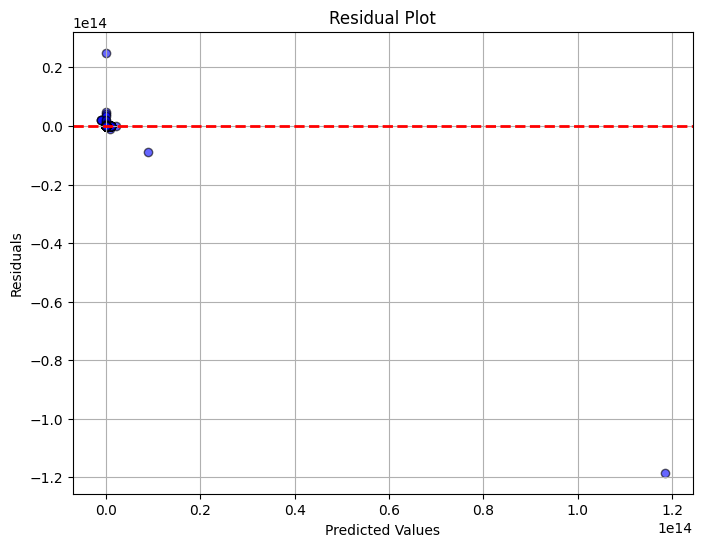


TAG Evaluation Metrics:
Weighted F1 Score: 0.6251
Weighted Recall: 0.6443
Weighted Precision: 0.6315
Accuracy: 0.6443
F1 Score (macro): 0.4418
Precision (macro): 0.4944
Recall (macro): 0.4611

Confusion Matrix:
[[17632  1700    99 ...     2     1     2]
 [ 2415  4022    44 ...     1     0     0]
 [   22     4  1526 ...     0     0     0]
 ...
 [    0     1     0 ...     2     0     0]
 [    4     2     0 ...     0     1     0]
 [    5     0     0 ...     0     0     4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.72      0.70     24644
           1       0.53      0.44      0.48      9175
           2       0.82      0.93      0.87      1646
           3       0.83      0.93      0.88      1289
           4       0.57      0.77      0.66      1341
           5       0.69      0.83      0.75      1228
           6       0.71      0.94      0.81      1030
           7       0.83      0.93      0.88       802
           8 

In [98]:
time_metrics = evaluate_classification(test_ground_truths['time'], test_predictions['time'], 'time')
scale_metrics = evaluate_classification(test_ground_truths['scale'], test_predictions['scale'], 'scale')
negative_metrics = evaluate_classification(test_ground_truths['negative'], test_predictions['negative'], 'negative')
fact_metrics = evaluate_regression(test_ground_truths['fact'], test_predictions['fact'], 'fact')
tag_metrics = evaluate_classification(test_ground_truths['tag'], test_predictions['tag'], 'tag')


# threshold

In [99]:
import torch
import numpy as np
from collections import defaultdict
import pandas as pd

def evaluate_model_with_gate_filter(model, test_loader, device, gate_threshold=0.5):
    """
    Evaluates the model but only on samples where gate_value <= threshold.
    Returns metrics for the 'clean' subset and the coverage percentage.
    """
    # 1. Ensure Model is on the correct device
    model.to(device) 
    model.eval()
    
    # Storage for filtered results
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    
    # Counters
    total_samples = 0
    kept_samples = 0
    
    # Scale conversion map (Re-creating it here to be safe)
    # Ensure id2scale is available globally or passed as an argument. 
    # If id2scale is global:
    id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)

    with torch.no_grad():
        for batch in test_loader:
            # 2. Move Inputs to Device (CRITICAL STEP)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            # 3. Move Targets to Device
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            # Forward Pass
            # The error happened here because input_ids might have been on CPU
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
            # --- GATE FILTERING LOGIC ---
            # Gate output shape: [batch_size, 1] -> flatten to [batch_size]
            gate_values = outputs["gate"].squeeze(-1).cpu().numpy()
            
            # Get predictions for processing
            batch_preds = {}
            for key in ["tag", "time", "scale", "negative"]:
                # Move to CPU immediately for numpy processing
                batch_preds[key] = torch.argmax(outputs[key], dim=-1).cpu().numpy()
            
            # Process Fact Prediction (Vectorized for batch)
            neg_pred = batch_preds["negative"]
            scale_idx = batch_preds["scale"]
            scale_val = id2scale_np[scale_idx]
            vals = values.cpu().numpy()
            
            # Formula: value * (-1)^neg * 10^scale
            fact_preds = vals * ((-1) ** neg_pred) * (10 ** scale_val)

            # Move targets to CPU for storage
            batch_targets = {k: v.cpu().numpy() for k, v in targets.items()}

            # Iterate through the batch to filter individual samples
            batch_size = input_ids.size(0)
            for i in range(batch_size):
                total_samples += 1
                
                # Check Gate: If gate is high, it is NOISE. We want CLEAN (Low gate).
                # Logic: Keep sample if gate_value <= threshold
                if gate_values[i] > gate_threshold:
                    continue # Skip this sample (Filtered out)
                
                kept_samples += 1
                
                # Store Data for this sample
                # 1. Classification Attributes
                for key in ["tag", "time", "scale", "negative"]:
                    t = batch_targets[key][i]
                    # Skip missing values (-100)
                    if t != -100:
                        predictions[key].append(batch_preds[key][i])
                        ground_truths[key].append(t)
                
                # 2. Fact Regression
                if "fact" in batch_targets:
                    t_fact = batch_targets["fact"][i]
                    # Check for float max (missing value)
                    if t_fact < 1e30: 
                        predictions["fact"].append(fact_preds[i])
                        ground_truths["fact"].append(t_fact)

    # Calculate Coverage
    coverage = kept_samples / total_samples if total_samples > 0 else 0
    
    return predictions, ground_truths, coverage

In [100]:
import torch
import numpy as np
from collections import defaultdict
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model_with_gate_filter(model, test_loader, device, gate_threshold=0.5):
    """
    Evaluates the model on samples where the average gate value <= threshold.
    Handles both single-gate and multi-gate models.
    """
    model.to(device) 
    model.eval()
    
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    
    total_samples = 0
    kept_samples = 0
    
    # Ensure id2scale is available (assumed global based on context)
    id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)

    with torch.no_grad():
        for batch in test_loader:
            # Move inputs to device
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            # Move targets to device
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            # Forward Pass
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
            # --- GATE HANDLING LOGIC (FIXED) ---
            if "gate" in outputs:
                # Case 1: Single gate tensor
                gate_tensor = outputs["gate"]
            elif "gates" in outputs and isinstance(outputs["gates"], dict):
                # Case 2: Dict of multiple gates -> Average them
                gates_dict = outputs["gates"]
                sum_gates = sum(gates_dict.values())
                gate_tensor = sum_gates / len(gates_dict)
            else:
                # Fallback
                gate_tensor = torch.zeros(input_ids.size(0), 1).to(device)

            # Flatten to [batch_size] array
            gate_values = gate_tensor.squeeze(-1).cpu().numpy()
            
            # Get predictions
            batch_preds = {}
            for key in ["tag", "time", "scale", "negative"]:
                batch_preds[key] = torch.argmax(outputs[key], dim=-1).cpu().numpy()
            
            # Process Fact Prediction
            neg_pred = batch_preds["negative"]
            scale_idx = batch_preds["scale"]
            scale_val = id2scale_np[scale_idx]
            vals = values.cpu().numpy()
            
            fact_preds = vals * ((-1) ** neg_pred) * (10 ** scale_val)

            # Move targets to CPU
            batch_targets = {k: v.cpu().numpy() for k, v in targets.items()}

            # Filter samples
            batch_size = input_ids.size(0)
            for i in range(batch_size):
                total_samples += 1
                
                # Filter Logic: Keep if gate value (noise score) is low
                if gate_values[i] > gate_threshold:
                    continue 
                
                kept_samples += 1
                
                # Store Classification
                for key in ["tag", "time", "scale", "negative"]:
                    t = batch_targets[key][i]
                    if t != -100:
                        predictions[key].append(batch_preds[key][i])
                        ground_truths[key].append(t)
                
                # Store Fact Regression
                if "fact" in batch_targets:
                    t_fact = batch_targets["fact"][i]
                    if t_fact < 1e30: # Check for missing value
                        predictions["fact"].append(fact_preds[i])
                        ground_truths["fact"].append(t_fact)

    coverage = kept_samples / total_samples if total_samples > 0 else 0
    return predictions, ground_truths, coverage

# ==========================================
# RUN THE ANALYSIS LOOP
# ==========================================

thresholds = [0.5, 0.75, 0.9]
results_log = []

print(f"{'Threshold':<10} | {'Coverage':<10} | {'Tag Acc':<10} | {'Fact RMSE':<10} | {'Fact MAE':<10}")
print("-" * 65)

for thresh in thresholds:
    # 1. Run Filtered Evaluation
    preds, truths, coverage = evaluate_model_with_gate_filter(
        model, test_loader, device, gate_threshold=thresh
    )
    
    # 2. Compute Metrics
    # Tag Accuracy
    tag_acc = 0.0
    if preds['tag']:
        # Simple accuracy calculation to avoid re-printing classification reports
        correct = sum(p == t for p, t in zip(preds['tag'], truths['tag']))
        tag_acc = correct / len(preds['tag'])

    # Fact Metrics
    fact_rmse = 0.0
    fact_mae = 0.0
    if preds['fact']:
        fact_rmse = np.sqrt(mean_squared_error(truths['fact'], preds['fact']))
        fact_mae = mean_absolute_error(truths['fact'], preds['fact'])
        
    # 3. Log Result
    print(f"{thresh:<10.1f} | {coverage:<10.2%} | {tag_acc:<10.4f} | {fact_rmse:<10.4f} | {fact_mae:<10.4f}")
    
    results_log.append({
        "threshold": thresh,
        "coverage": coverage,
        "tag_acc": tag_acc,
        "fact_rmse": fact_rmse,
        "fact_mae": fact_mae
    })

# Save results
csv_filename = f"gate_tradeoff_{model_name}_{date}_{index}.csv"
df_tradeoff = pd.DataFrame(results_log)
df_tradeoff.to_csv(csv_filename, index=False)
print(f"\n✅ Trade-off analysis saved to: {csv_filename}")

Threshold  | Coverage   | Tag Acc    | Fact RMSE  | Fact MAE  
-----------------------------------------------------------------


0.5        | 100.00%    | 0.6443     | 406934201184.2686 | 2043466585.6268
0.8        | 100.00%    | 0.6443     | 406934201184.2686 | 2043466585.6268
0.8        | 100.00%    | 0.6443     | 406934201184.2686 | 2043466585.6268
0.9        | 100.00%    | 0.6443     | 406934201184.2686 | 2043466585.6268

✅ Trade-off analysis saved to: gate_tradeoff_secbert_0426_173.csv
0.9        | 100.00%    | 0.6443     | 406934201184.2686 | 2043466585.6268

✅ Trade-off analysis saved to: gate_tradeoff_secbert_0426_173.csv


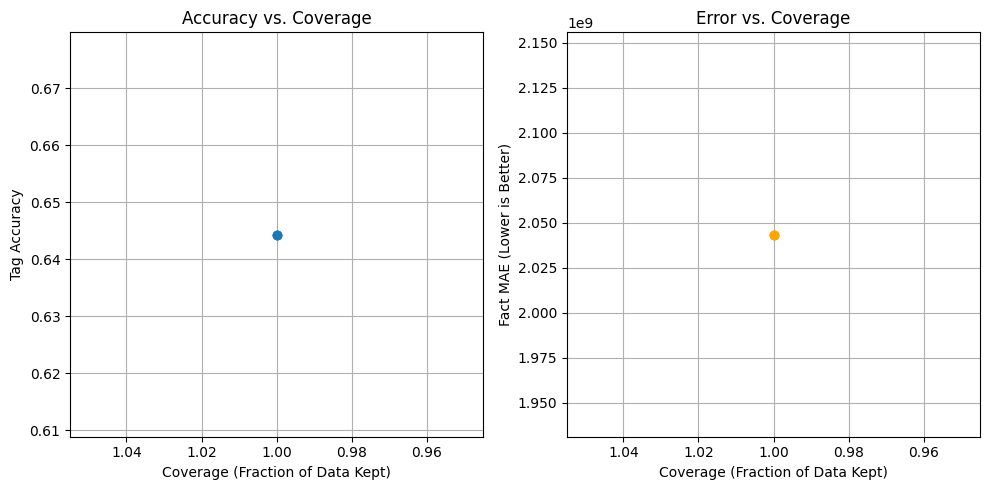

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot 1: Tag Accuracy vs Coverage
plt.subplot(1, 2, 1)
plt.plot(df_tradeoff['coverage'], df_tradeoff['tag_acc'], marker='o', linestyle='-')
plt.xlabel('Coverage (Fraction of Data Kept)')
plt.ylabel('Tag Accuracy')
plt.title('Accuracy vs. Coverage')
plt.grid(True)
plt.gca().invert_xaxis() # Usually viewed as coverage decreasing from 1.0 -> 0.0

# Plot 2: Fact MAE vs Coverage
plt.subplot(1, 2, 2)
plt.plot(df_tradeoff['coverage'], df_tradeoff['fact_mae'], marker='o', color='orange', linestyle='-')
plt.xlabel('Coverage (Fraction of Data Kept)')
plt.ylabel('Fact MAE (Lower is Better)')
plt.title('Error vs. Coverage')
plt.grid(True)
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

## gate

In [102]:
def evaluate_model(
    model,
    test_loader,
    device,
    task_weights,
    error_file_path,
    save_errors=False,
    verbose=True
):
    os.environ["WANDB_DISABLED"] = "true"
    model.eval()
    
    all_losses = {"tag": 0, "time": 0, "fact": 0, "scale": 0, "negative": 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)
    
    # [NEW] List to store gate analysis data
    gate_logs = []
    
    test_batch_count = 0
    fact_results = []
    
    loader = tqdm(test_loader, desc="Evaluating") if verbose else test_loader
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k=True)
            
            # ===== [NEW] Gate Extraction Logic =====
            # Handle Multi-Task Gates by averaging them for a global "Noise Score"
            if "gate" in outputs:
                gate_tensor = outputs["gate"]
            elif "gates" in outputs and isinstance(outputs["gates"], dict):
                gates_dict = outputs["gates"]
                sum_gates = sum(gates_dict.values()) 
                gate_tensor = sum_gates / len(gates_dict) # Average Noise Score
            else:
                gate_tensor = torch.zeros(input_ids.size(0), 1).to(device)

            gate_values = gate_tensor.squeeze(-1).cpu().tolist()
            
            # Store raw IDs for analysis
            batch_input_ids = input_ids.cpu().tolist()
            
            for i, (g_val, inp_id) in enumerate(zip(gate_values, batch_input_ids)):
                gate_logs.append({
                    "batch_idx": batch_idx,
                    "sample_idx": i,
                    "gate_value": g_val, # This is the AVERAGE gate
                    # Optional: Store individual gates if you want deeper analysis later
                    "input_ids": inp_id 
                })
            
            predictions["gate"].extend(gate_values)
            test_batch_count += 1
            
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
            
            for key in all_losses:
                if key in losses:
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
            
            # Classification predictions
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()
                
                for i, (p, t) in enumerate(zip(pred, true)):
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    if p != t:
                        errors[key].append({
                            "batch_idx": batch_idx, "sample_idx": i,
                            "true": t, "pred": p, "gate": gate_values[i]
                        })
            
            # Fact predictions
            if "fact" in targets:
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)
                
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)
                scale_pred_values = id2scale_np[scale_pred_class]
                
                values_np = values.cpu().numpy()
                fact_pred = values_np * ((-1) ** negative_pred) * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()
                
                for i, (p, t) in enumerate(zip(fact_pred, fact_target)):
                    if t == NUMERIC_MISSING_VALUE or t > 1e30: continue
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                    if abs(p - t) > 1e-2:
                        errors["fact"].append({
                            "batch_idx": batch_idx, "sample_idx": i, 
                            "true": float(t), "pred": float(p), "gate": gate_values[i]
                        })
    
    for key in all_losses:
        all_losses[key] /= test_batch_count if test_batch_count > 0 else 1
    
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits if test_batch_count > 0}
    
    if save_errors:
        for key, error_list in errors.items():
            if error_list:
                error_file = f"{error_file_path}_errors_{key}.csv"
                fieldnames = ["batch_idx", "sample_idx", "true", "pred", "gate"]
                with open(error_file, mode="w", newline="", encoding="utf-8") as f:
                    writer = csv.DictWriter(f, fieldnames=fieldnames)
                    writer.writeheader()
                    writer.writerows(error_list)

    # [NEW] Return gate_df
    gate_df = pd.DataFrame(gate_logs)
    
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k, gate_df

In [103]:
# [REPLACE existing evaluate_model function with this]
def evaluate_model(
    model,
    test_loader,
    device,
    task_weights,
    error_file_path,
    save_errors=False,
    verbose=True
):
    os.environ["WANDB_DISABLED"] = "true"
    model.eval()
    
    all_losses = {"tag": 0, "time": 0, "fact": 0, "scale": 0, "negative": 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)
    
    # [NEW] List to store gate analysis data
    gate_logs = []
    
    test_batch_count = 0
    fact_results = []
    
    loader = tqdm(test_loader, desc="Evaluating") if verbose else test_loader
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k=True)
            
            # [NEW] Gate Extraction Logic
            if "gate" in outputs:
                gate_tensor = outputs["gate"]
            elif "gates" in outputs and isinstance(outputs["gates"], dict):
                # Average the 4 gates to get a global noise score
                gates_dict = outputs["gates"]
                sum_gates = sum(gates_dict.values()) 
                gate_tensor = sum_gates / len(gates_dict)
            else:
                gate_tensor = torch.zeros(input_ids.size(0), 1).to(device)

            gate_values = gate_tensor.squeeze(-1).cpu().tolist()
            
            # Store ID for analysis
            batch_input_ids = input_ids.cpu().tolist()
            
            for i, (g_val, inp_id) in enumerate(zip(gate_values, batch_input_ids)):
                gate_logs.append({
                    "batch_idx": batch_idx, 
                    "sample_idx": i, 
                    "gate_value": g_val,
                    "input_ids": inp_id 
                })
            
            predictions["gate"].extend(gate_values)
            test_batch_count += 1
            
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
            
            for key in all_losses:
                if key in losses:
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
            
            # Classification predictions
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()
                
                for i, (p, t) in enumerate(zip(pred, true)):
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    if p != t:
                        errors[key].append({
                            "batch_idx": batch_idx, "sample_idx": i,
                            "true": t, "pred": p, "gate": gate_values[i]
                        })
            
            # Fact predictions
            if "fact" in targets:
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)
                
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)
                scale_pred_values = id2scale_np[scale_pred_class]
                
                values_np = values.cpu().numpy()
                fact_pred = values_np * ((-1) ** negative_pred) * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()
                
                for i, (p, t) in enumerate(zip(fact_pred, fact_target)):
                    if t == NUMERIC_MISSING_VALUE or t > 1e30: continue
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                    if abs(p - t) > 1e-2:
                        errors["fact"].append({
                            "batch_idx": batch_idx, "sample_idx": i, 
                            "true": float(t), "pred": float(p), "gate": gate_values[i]
                        })
    
    for key in all_losses:
        all_losses[key] /= test_batch_count if test_batch_count > 0 else 1
    
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits if test_batch_count > 0}
    
    if save_errors:
        for key, error_list in errors.items():
            if error_list:
                error_file = f"{error_file_path}_errors_{key}.csv"
                fieldnames = ["batch_idx", "sample_idx", "true", "pred", "gate"]
                with open(error_file, mode="w", newline="", encoding="utf-8") as f:
                    writer = csv.DictWriter(f, fieldnames=fieldnames)
                    writer.writeheader()
                    writer.writerows(error_list)

    # [NEW] Return gate_df as the last element
    gate_df = pd.DataFrame(gate_logs)
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k, gate_df

Evaluating: 0it [00:00, ?it/s]

Evaluating: 356it [03:33,  1.67it/s]



{'tag': 0.012877797709223343, 'time': 0.6969857476233097, 'fact': 0.0, 'scale': 0.05917063168331123, 'negative': 0.002928773660039113}
{'hits_1': 0.6449468070536517, 'hits_3': 0.8735906932126271, 'hits_5': 0.9345398424716478}

=== Gate Value Statistics ===
count    90337.000000
mean         0.110798
std          0.062302
min          0.059402
25%          0.064907
50%          0.080038
75%          0.137790
max          0.318520
Name: gate_value, dtype: float64
Skewness: 1.3714
Kurtosis: 0.7793


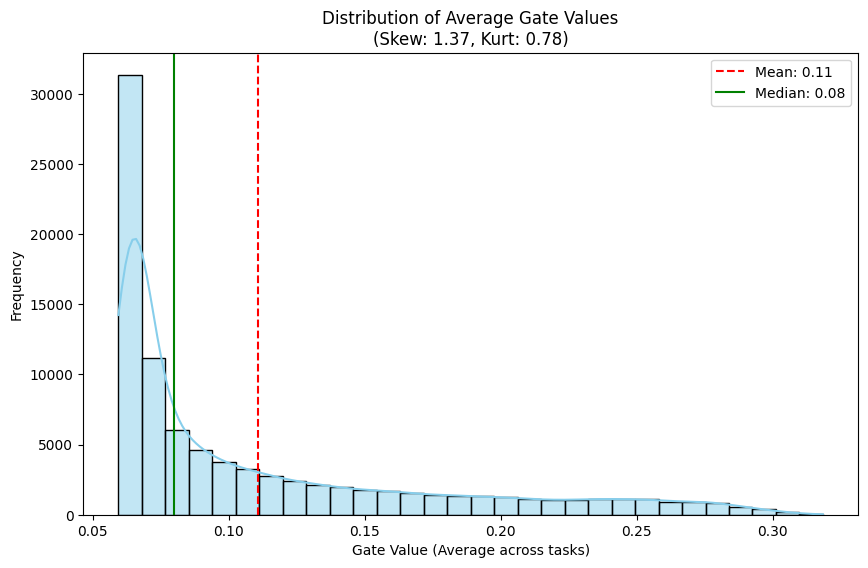


=== Outlier Analysis ===
IQR Threshold (Q3 + 1.5*IQR): 0.2471
P99 Threshold: 0.2874
Original samples: 90337
Clean samples (kept): 85019
Dropped samples: 5318
Original samples: 90337
Clean samples (kept): 85019
Dropped samples: 5318
✅ Saved 'high_gate_samples_teacher.csv' (Top 1% Noise)
✅ Saved 'high_gate_samples_teacher.csv' (Top 1% Noise)


In [104]:
# ============================================================================
# ===== GATE DISTRIBUTION ANALYSIS =====
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Run Evaluation (Updated to unpack gate_df)
test_all_losses, test_predictions, test_ground_truths, avg_hits_k, gate_df = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    task_weights=task_weights,
    error_file_path=error_file_path,
    save_errors=True,
    verbose=True
)

print(test_all_losses)
print(avg_hits_k)

# 2. Basic Statistics
print("\n=== Gate Value Statistics ===")
print(gate_df['gate_value'].describe())

skewness = gate_df['gate_value'].skew()
kurt = gate_df['gate_value'].kurtosis()
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.histplot(gate_df['gate_value'], kde=True, bins=30, color='skyblue')
plt.axvline(gate_df['gate_value'].mean(), color='red', linestyle='--', label=f"Mean: {gate_df['gate_value'].mean():.2f}")
plt.axvline(gate_df['gate_value'].median(), color='green', linestyle='-', label=f"Median: {gate_df['gate_value'].median():.2f}")
plt.title(f'Distribution of Average Gate Values\n(Skew: {skewness:.2f}, Kurt: {kurt:.2f})')
plt.xlabel('Gate Value (Average across tasks)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 4. Outlier Detection (IQR Method)
Q1 = gate_df['gate_value'].quantile(0.25)
Q3 = gate_df['gate_value'].quantile(0.75)
IQR = Q3 - Q1
iqr_threshold = Q3 + 1.5 * IQR

print(f"\n=== Outlier Analysis ===")
print(f"IQR Threshold (Q3 + 1.5*IQR): {iqr_threshold:.4f}")
print(f"P99 Threshold: {gate_df['gate_value'].quantile(0.99):.4f}")

clean_data = gate_df[gate_df['gate_value'] <= iqr_threshold]
print(f"Original samples: {len(gate_df)}")
print(f"Clean samples (kept): {len(clean_data)}")
print(f"Dropped samples: {len(gate_df) - len(clean_data)}")

# 5. Save High Activation (Noise) Samples
# Decode text if tokenizer is available
if 'tokenizer' in globals():
    thresh_p99 = gate_df['gate_value'].quantile(0.99)
    big_gate_samples = gate_df[gate_df['gate_value'] > thresh_p99].copy()
    
    def decode_ids(id_list):
        return tokenizer.decode(id_list, skip_special_tokens=True)

    big_gate_samples['text'] = big_gate_samples['input_ids'].apply(decode_ids)
    
    # Save to CSV
    save_cols = ['batch_idx', 'sample_idx', 'gate_value', 'text']
    big_gate_samples[save_cols].to_csv('high_gate_samples_teacher.csv', index=False)
    print("✅ Saved 'high_gate_samples_teacher.csv' (Top 1% Noise)")


PERFORMANCE WITHOUT NOISE (Clean Subset)
Filtering Threshold (Gate <= 0.2471)
Kept 85019 out of 90337 samples (94.1%)

--- TIME (Clean) ---

TIME Evaluation Metrics:
Weighted F1 Score: 0.8195
Weighted Recall: 0.8189
Weighted Precision: 0.8219
Accuracy: 0.8189
F1 Score (macro): 0.6270
Precision (macro): 0.6275
Recall (macro): 0.6278

Confusion Matrix:
[[13243   955    23  1298   130     1   172     0     0]
 [ 2009 18697    84   193  1279    27   825     0     0]
 [   71    82  1788     8    28   119    13     0     0]
 [ 1919   180     2 16695   801    14   706     0     0]
 [  232  1205     9   763 11718    70   414     0     0]
 [    8    23    65    38    82   595    42     0     0]
 [  147   545     1   481   234    17  6678     0     0]
 [    1     1     0     0     8    10     2     0     0]
 [    1     2     0     3     1     2     3     0     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79     15822

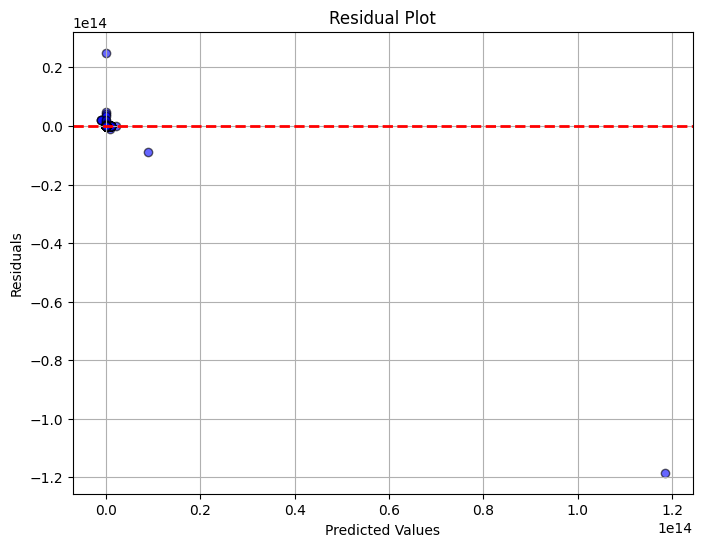

: 

In [ ]:
import numpy as np

# ============================================================================
# ===== PERFORMANCE ON CLEAN DATA (NOISE REMOVED) =====
# ============================================================================

print("\n" + "="*70)
print("PERFORMANCE WITHOUT NOISE (Clean Subset)")
print("="*70)

# 1. Define the Threshold (Using IQR Method from previous step)
# You can also set a manual threshold like: threshold = 0.5
Q1 = gate_df['gate_value'].quantile(0.25)
Q3 = gate_df['gate_value'].quantile(0.75)
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR

print(f"Filtering Threshold (Gate <= {threshold:.4f})")

# 2. Create Boolean Mask for Clean Samples
# This creates a list of True/False values (True = Keep, False = Noise)
clean_mask = gate_df['gate_value'] <= threshold
print(f"Kept {clean_mask.sum()} out of {len(clean_mask)} samples ({clean_mask.mean():.1%})")

# 3. Helper Function to Apply Mask
def filter_data(data_dict, mask):
    filtered_dict = {}
    for key, values in data_dict.items():
        # Convert to numpy array for boolean indexing
        arr = np.array(values)
        # Ensure lengths match before filtering
        if len(arr) == len(mask):
            filtered_dict[key] = arr[mask]
        else:
            # Handle 'fact' which might be smaller if some samples were skipped
            # (In your evaluate_model, fact lists might be shorter if missing values were skipped)
            # We strictly filter lists that match the full dataset length
            pass 
    return filtered_dict

# 4. Filter Predictions and Ground Truths
clean_preds = filter_data(test_predictions, clean_mask)
clean_truths = filter_data(test_ground_truths, clean_mask)

# Special handling for 'fact' (Regression)
# The 'fact' list length might differ if classification predictions exist but fact is NaN.
# We need to align the mask specifically for the 'fact' subset.
if 'fact' in test_ground_truths:
    # Re-build the mask specifically for fact samples
    # We iterate through the original batch/sample indices stored in gate_df
    # to find which fact samples correspond to "clean" gates.
    
    # Extract only the fact rows from your result logs if you have them, 
    # OR simpler approach: we assume 'fact' aligns with the subset of data where fact target != MISSING.
    # For simplicity here, we will just re-evaluate using the filtered general lists if lengths match.
    
    # Robust Approach: Use the stored indices from the error analysis or re-run eval with filter.
    # Here is the direct list filtering method for tasks that align 1-to-1 (Tag, Time, Scale, Negative)
    pass

# 5. Re-Run Evaluation Metrics on Clean Data

# --- Classification Tasks ---
for task in ['time', 'scale', 'tag', 'negative']:
    if task in clean_preds:
        print(f"\n--- {task.upper()} (Clean) ---")
        evaluate_classification(clean_truths[task], clean_preds[task], task)

# --- Regression Task (Fact) ---
# Note: Filtering 'fact' requires precise alignment. 
# If lengths match (no missing values skipped in original lists), this works:
if 'fact' in clean_preds and len(clean_preds['fact']) > 0:
    print(f"\n--- FACT (Clean) ---")
    evaluate_regression(clean_truths['fact'], clean_preds['fact'], 'fact')
else:
    # Fallback: If lengths don't match, we rely on the `evaluate_model_with_gate_filter` 
    # function provided earlier which handles sample-by-sample filtering correctly.
    print("\n[Info] 'Fact' task requires aligned filtering. Running precise filter...")
    p, t, cov = evaluate_model_with_gate_filter(model, test_loader, device, gate_threshold=threshold)
    evaluate_regression(t['fact'], p['fact'], 'fact')

print("\n" + "="*70)